In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

from src.config import GLOVE_MODEL, WORD2VEC_MODEL, ENABLE_WORD2VEC
from src.embeddings.prediction import PretrainedWordEmbedder
from src.evaluation.visualization import plot_pca_embeddings, plot_tsne_embeddings, plot_embedding_comparison

In [ ]:
WORDS_TO_VISUALIZE = [
    "good", "bad", "great", "terrible", "happy", "sad", "angry",
    "food", "eat", "restaurant", "delicious", "horrible",
    "love", "hate", "joy", "sorrow", "fight", "peace"
]

glove_embedder = PretrainedWordEmbedder(model_name=GLOVE_MODEL)
glove_vectors = np.array([glove_embedder.model[word] for word in WORDS_TO_VISUALIZE if word in glove_embedder.model])
glove_words = [word for word in WORDS_TO_VISUALIZE if word in glove_embedder.model]

print(f"Extracted {len(glove_words)} GloVe embeddings for visualization.")

plot_pca_embeddings(glove_words, glove_vectors, filename="pca_glove_embeddings.png")
plot_tsne_embeddings(glove_words, glove_vectors, filename="tsne_glove_embeddings.png")

embeddings_to_compare = {"GloVe": glove_vectors}

if ENABLE_WORD2VEC:
    try:
        word2vec_embedder = PretrainedWordEmbedder(model_name=WORD2VEC_MODEL)
        word2vec_vectors = np.array([word2vec_embedder.model[word] for word in WORDS_TO_VISUALIZE if word in word2vec_embedder.model])
        word2vec_words = [word for word in WORDS_TO_VISUALIZE if word in word2vec_embedder.model]
        print(f"Extracted {len(word2vec_words)} Word2Vec embeddings for visualization.")

        plot_pca_embeddings(word2vec_words, word2vec_vectors, filename="pca_word2vec_embeddings.png")
        plot_tsne_embeddings(word2vec_words, word2vec_vectors, filename="tsne_word2vec_embeddings.png")
        embeddings_to_compare["Word2Vec"] = word2vec_vectors

    except (MemoryError, RuntimeError) as exc:
        print(f"Skipping Word2Vec visualizations because it does not fit in memory or other error occurred: {exc}")

if len(embeddings_to_compare) > 1:
    plot_embedding_comparison(WORDS_TO_VISUALIZE, embeddings_to_compare, filename="embedding_comparison.png")
else:
    print("Only one set of embeddings available for comparison, skipping comparison plot.")

Extracted 18 GloVe embeddings for visualization.
Generating PCA visualization...
PCA plot saved to results/pca_glove_embeddings.png
Variance explained: PC1=19.98%, PC2=17.84%
Generating t-SNE visualization...
t-SNE plot saved to results/tsne_glove_embeddings.png
Extracted 18 Word2Vec embeddings for visualization.
Generating PCA visualization...
PCA plot saved to results/pca_word2vec_embeddings.png
Variance explained: PC1=17.94%, PC2=14.24%
Generating t-SNE visualization...
t-SNE plot saved to results/tsne_word2vec_embeddings.png
Generating embedding comparison visualization...
Comparison plot saved to results/embedding_comparison.png



In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"

def show_image(image_path: Path, title: str | None = None, figsize=(8, 6)) -> None:
    """Display one image if it exists.
    
    Args:
        image_path: Path to the image file to display.
        title: Optional title to show above the image.
        figsize: Size of the figure to display.
    """
    if not image_path.exists():
        print(f"Missing image: {image_path.name}")
        return

    img = Image.open(image_path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def show_table(csv_path: Path, title: str) -> pd.DataFrame:
    """Load and display one summary table.
    
    Args:
        csv_path: Path to the CSV file containing the table data.
        title: Title to display above the table.

    Returns:
        The DataFrame loaded from the CSV file, or an empty DataFrame if the file is missing.
    """
    if not csv_path.exists():
        print(f"Missing CSV: {csv_path.name}")
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    display(Markdown(f"### {title}"))
    display(df)
    return df

In [3]:
module1_df = show_table(RESULTS_DIR / "module1_summary.csv", "Module 1 Summary")
module2_df = show_table(RESULTS_DIR / "module2_summary.csv", "Module 2 Summary")
module3_df = show_table(RESULTS_DIR / "module3_summary.csv", "Module 3 Summary")

### Module 1 Summary

,Model,Accuracy,Precision,Recall,F1
0,LogReg_cbow,0.572371,0.578516,0.572371,0.562488
1,LogReg_tfidf,0.573185,0.583127,0.573185,0.561037


### Module 2 Summary

,Model,Accuracy,Precision,Recall,F1
0,RNN_GloVe,0.597037,0.628299,0.597037,0.586237
1,RNN_Word2Vec,0.622354,0.628020,0.622354,0.621943


### Module 3 Summary

,Model,Accuracy,Precision,Recall,F1
0,RNN_BERT,0.601189,0.639420,0.601189,0.59117
1,RNN_GPT,0.617796,0.643692,0.617796,0.61098


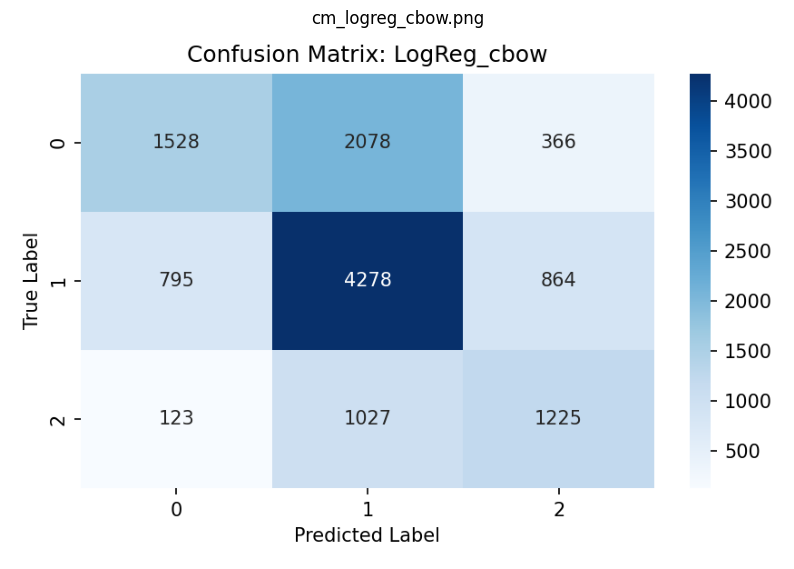

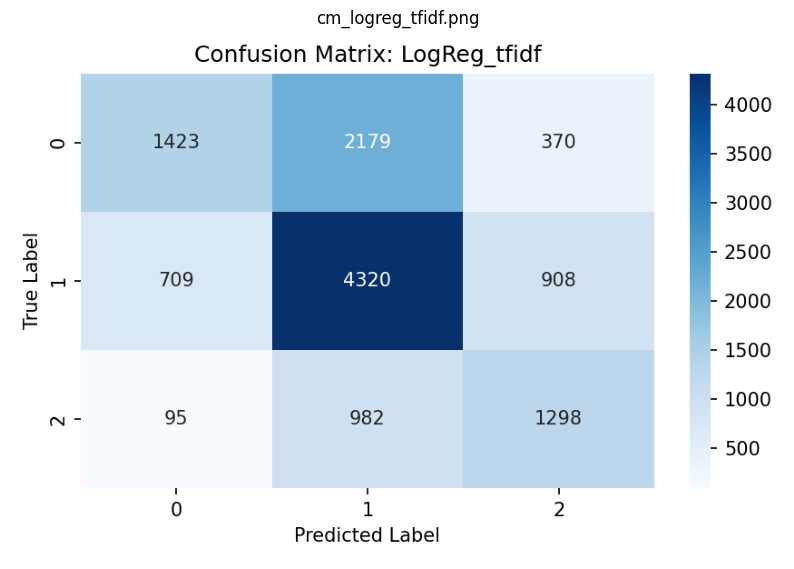

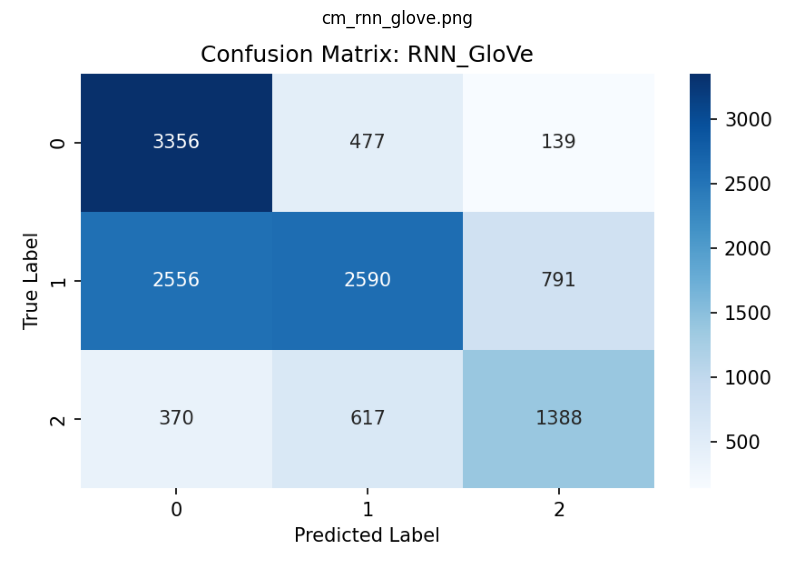

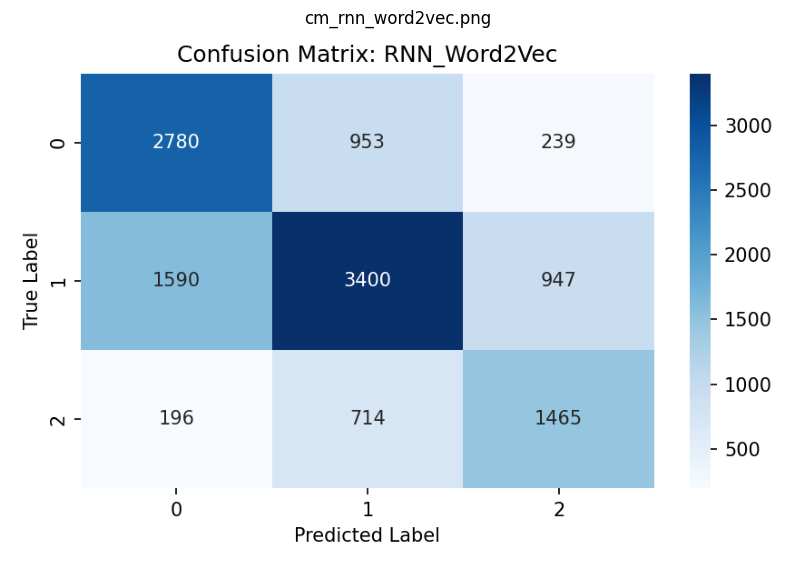

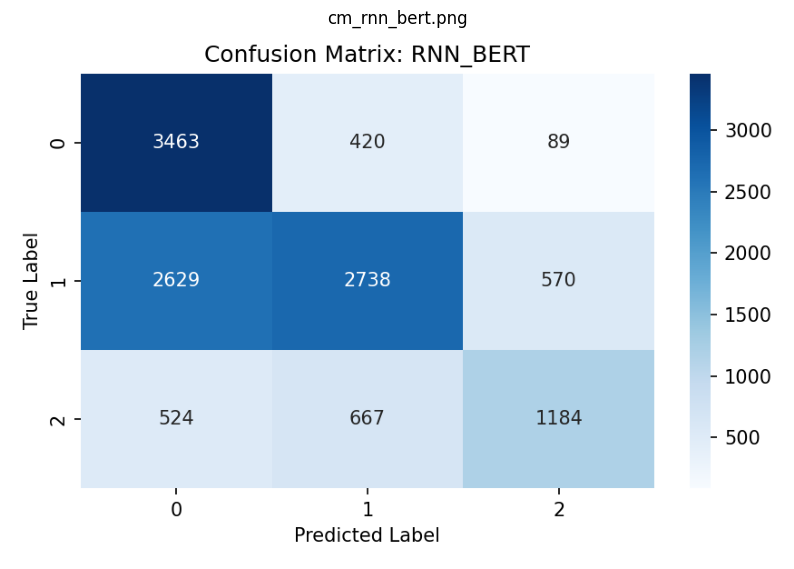

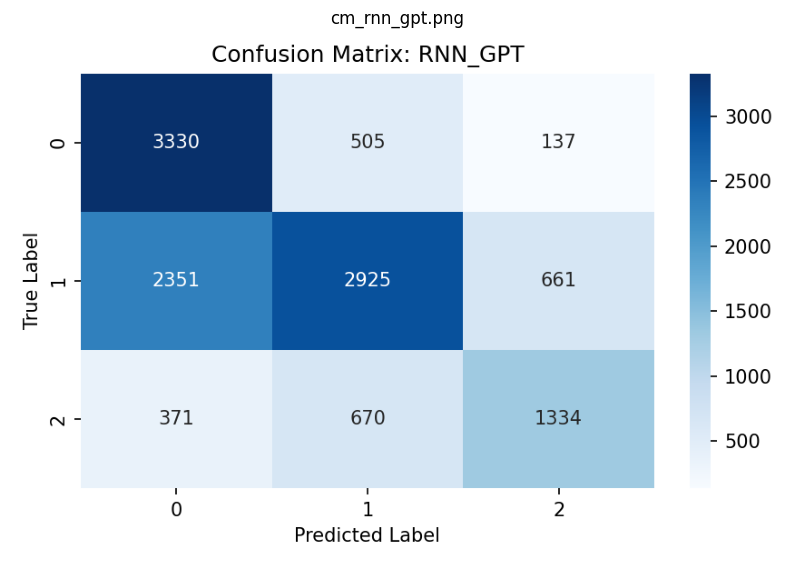

In [4]:
confusion_files = [
    "cm_logreg_cbow.png",
    "cm_logreg_tfidf.png",

    "cm_rnn_glove.png",
    "cm_rnn_word2vec.png",

    "cm_rnn_bert.png",
    "cm_rnn_gpt.png",

]

for filename in confusion_files:
    show_image(RESULTS_DIR / filename, title=filename, figsize=(10, 7))

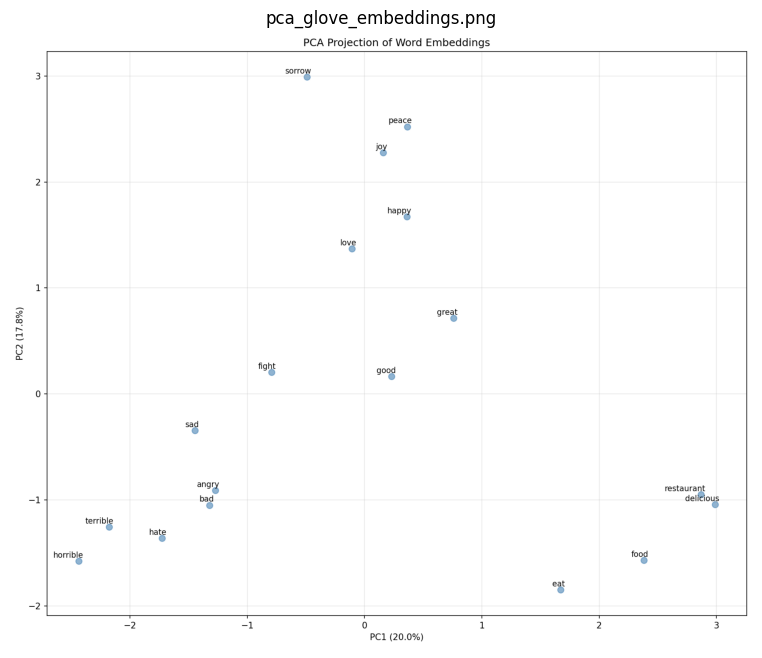

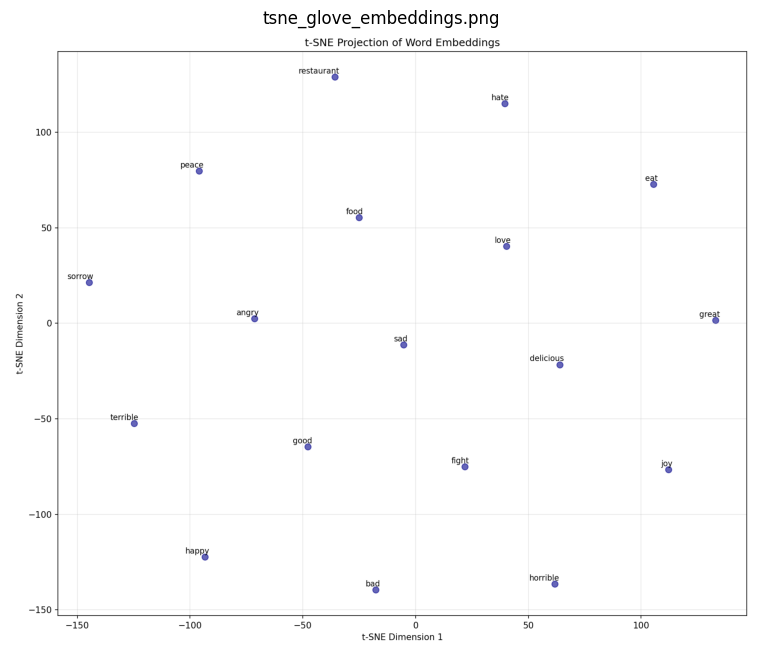

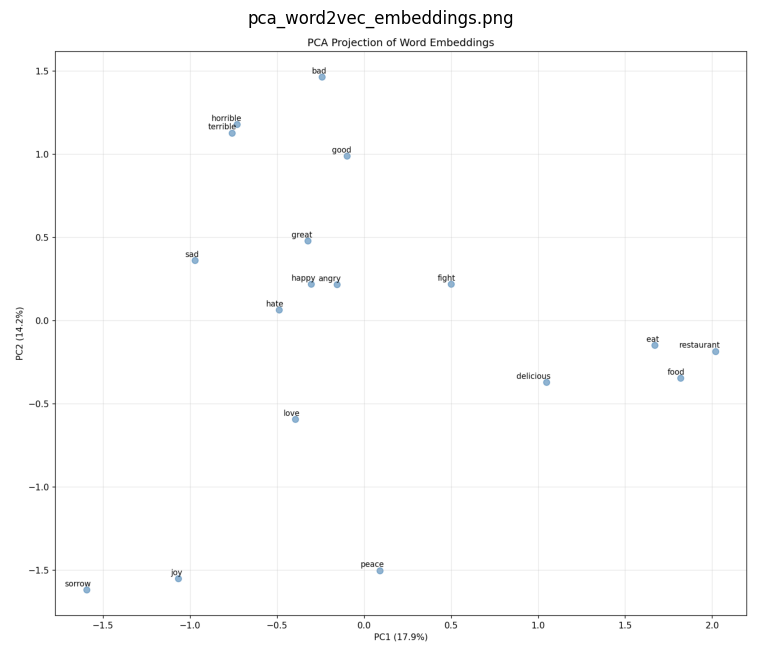

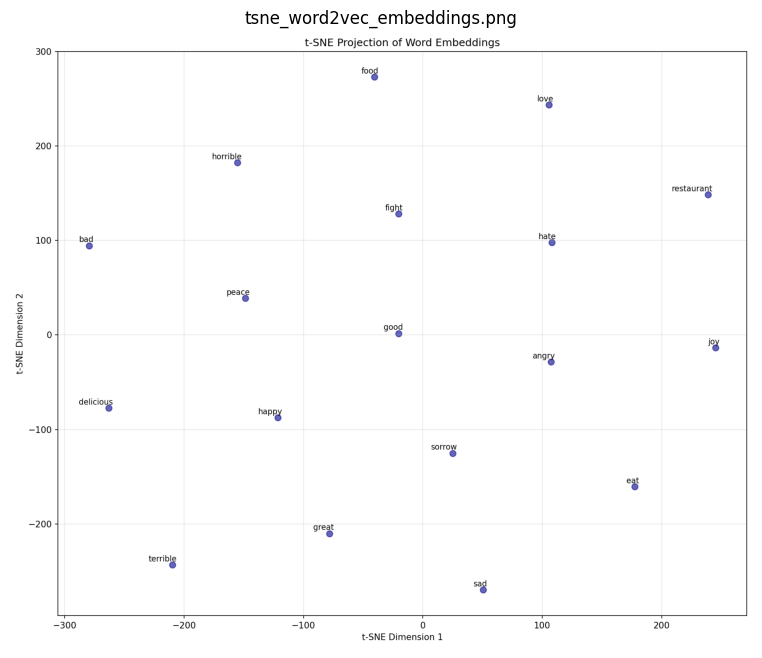

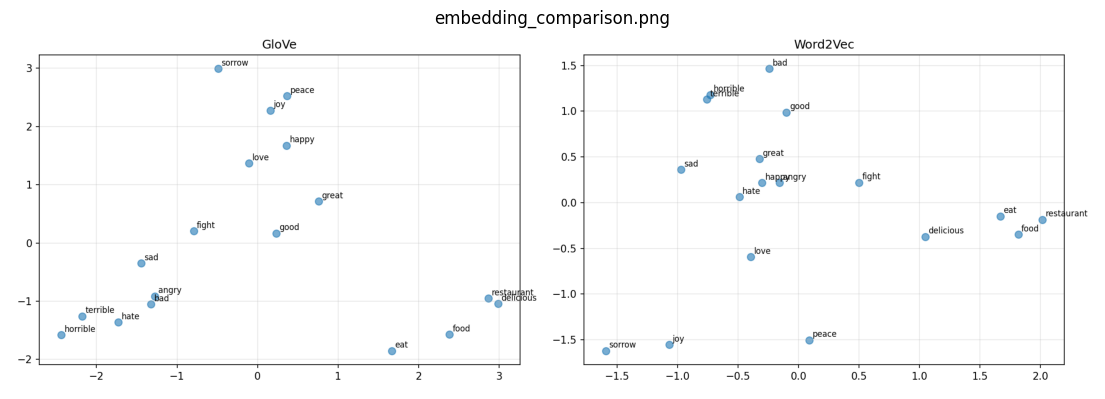

In [5]:
embedding_plot_files = [
    "pca_glove_embeddings.png",
    "tsne_glove_embeddings.png",

    "pca_word2vec_embeddings.png",
    "tsne_word2vec_embeddings.png",

    "embedding_comparison.png",
]

for filename in embedding_plot_files:
    show_image(RESULTS_DIR / filename, title=filename, figsize=(14, 8))